# Air Quality Forecasting - Exploration notebook

We want to predict PM2.5. This is a time series forecasting problem.

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sbn 
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

## 1. Load and prepare the data

In [2]:
# We first only focus on the Aotizhongxin location 
df = pd.read_csv("../data/raw/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv")
print(df.shape)
df.head()

(35064, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [3]:
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.sort_values("datetime").reset_index(drop=True)
new_order = ['datetime', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']
df = df[new_order]
df.head()

,datetime,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013-03-01 00:00:00,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2013-03-01 01:00:00,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,2013-03-01 02:00:00,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,2013-03-01 03:00:00,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,2013-03-01 04:00:00,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


### Check for missing timestamps

In [4]:
full_range = pd.date_range(df["datetime"].min(), df["datetime"].max(), freq="h")
missing_hours = full_range.difference(df["datetime"])
print(f"{len(missing_hours)} missing hours {len(full_range)}")

0 missing hours 35064


We have all the timepoints.

### Check for missing values (NaN)

In [5]:
nan_percentage = (df.isna().mean() * 100).round(2)
print(f"Percentage of nan per feature : \n {nan_percentage}")

Percentage of nan per feature : 
 datetime    0.00
year        0.00
month       0.00
day         0.00
hour        0.00
PM2.5       2.64
PM10        2.05
SO2         2.67
NO2         2.92
CO          5.07
O3          4.90
TEMP        0.06
PRES        0.06
DEWP        0.06
RAIN        0.06
wd          0.23
WSPM        0.04
station     0.00
dtype: float64


There are some NaN values, up to 5% for certain features. We use forward fill to avoid data leakage (no future information is used to fill past values).

In [6]:
df_filled = df.ffill()

### Encode categorical wind direction

We use one-hot encoding to convert the categorical wind direction (wd) into a numerical format. We use drop_first=True to avoid multicollinearity (the dummy variable trap), relevant if we later use linear models.

In [7]:
df_processed = pd.get_dummies(df_filled, columns =['wd'], dtype=int, drop_first=True)
df_processed.head()

,datetime,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW
0,2013-03-01 00:00:00,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,...,1,0,0,0,0,0,0,0,0,0
1,2013-03-01 01:00:00,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,...,0,0,0,0,0,0,0,0,0,0
2,2013-03-01 02:00:00,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,...,1,0,0,0,0,0,0,0,0,0
3,2013-03-01 03:00:00,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,...,0,1,0,0,0,0,0,0,0,0
4,2013-03-01 04:00:00,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,...,0,0,0,0,0,0,0,0,0,0


## 2. Correlation analysis

In [8]:
# List of numerical columns used throughout the rest of the analysis
features = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

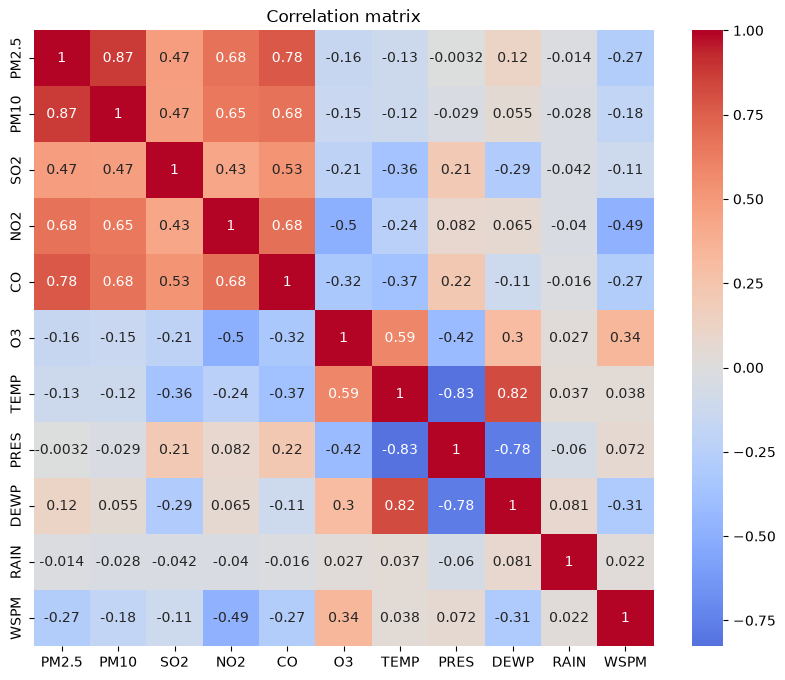

In [9]:
plt.figure(figsize=(10, 8))
sbn.heatmap(df_processed[features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation matrix")
plt.show()

PM2.5 is highly correlated with the other pollutants, since they largely share the same sources (traffic, industry). PM10 in particular is highly correlated with PM2.5 — we will try predicting the target with and without PM10, since removing it makes for a more interesting (less trivial) problem.

PM2.5 is negatively correlated with wind speed, which is consistent: wind helps dilute and disperse pollution.

TEMP, PRES and DEWP are highly correlated with each other. Worth keeping in mind if we use a linear model.

## 3. Target distribution

Text(0.5, 1.0, 'Distribution of PM2.5')

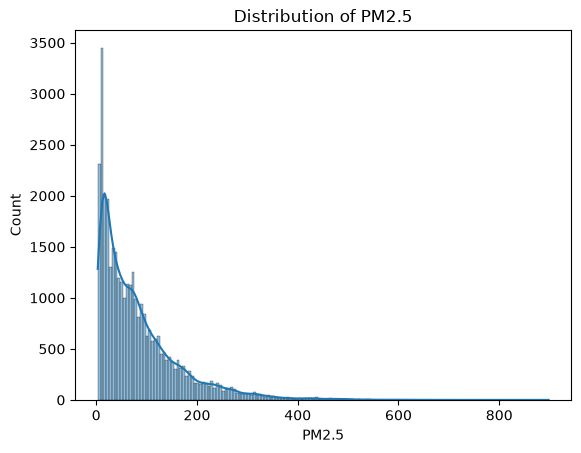

In [10]:
sbn.histplot(df_processed['PM2.5'], kde=True)
plt.title("Distribution of PM2.5")

Text(0.5, 1.0, 'Distribution of log(PM2.5)')

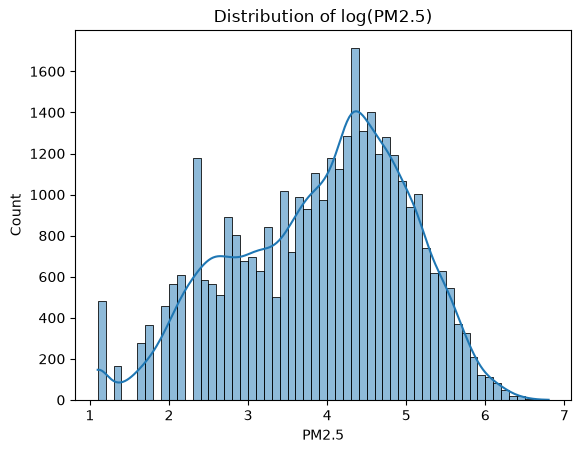

In [11]:
sbn.histplot(np.log(df_processed['PM2.5']), kde=True)
plt.title("Distribution of log(PM2.5)")

## 4. Seasonality analysis

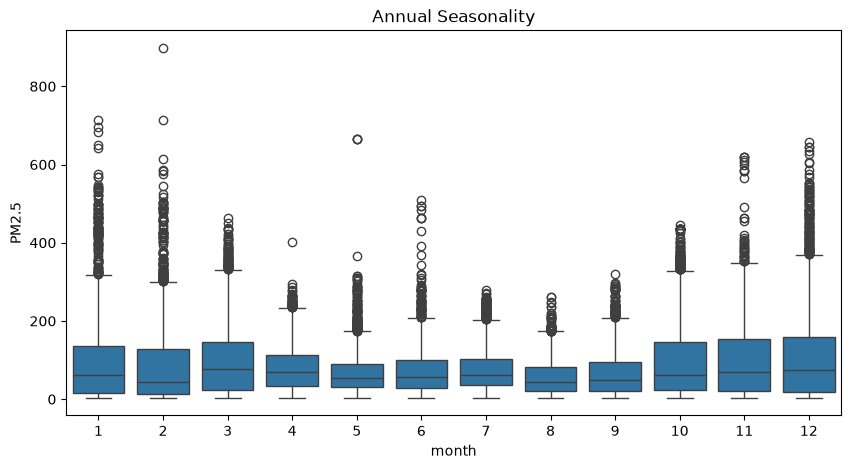

In [12]:
plt.figure(figsize=(10, 5))
sbn.boxplot(x='month', y='PM2.5', data=df_processed)
plt.title("Annual Seasonality")
plt.show()


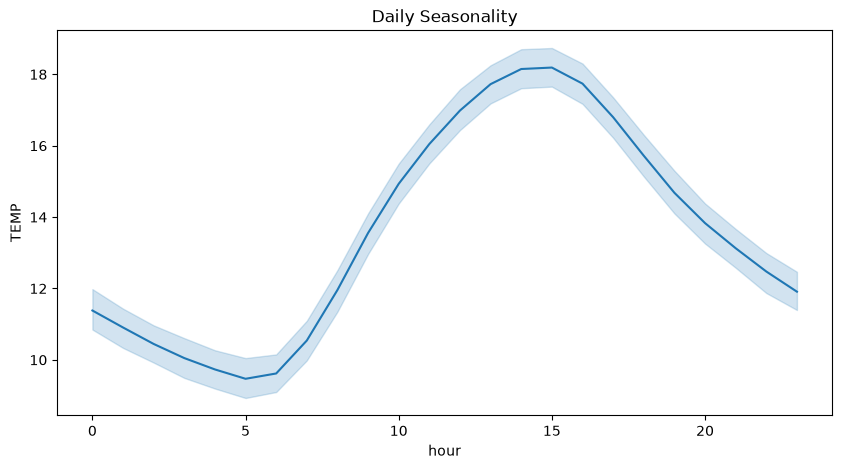

In [13]:
plt.figure(figsize=(10, 5))
sbn.lineplot(x='hour', y='TEMP', data=df_processed)
plt.title("Daily Seasonality")
plt.show()


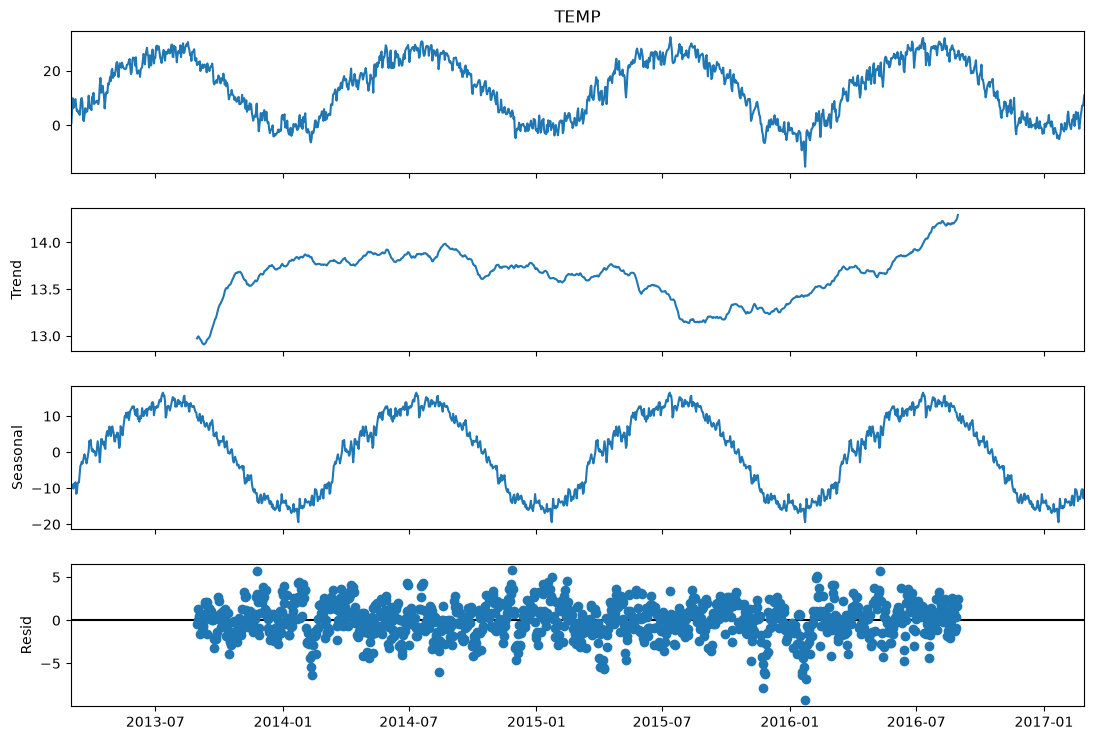

In [14]:
daily_data = df_processed.groupby(df_processed['datetime'].dt.date)['TEMP'].mean()

# period = 365 days so we get the trend over the year // additative is the right choice as there are no explosion of the feature of interest
decompo = seasonal_decompose(daily_data.dropna(), model='additive', period=365)

fig = decompo.plot()
fig.set_size_inches(12, 8)
plt.show()


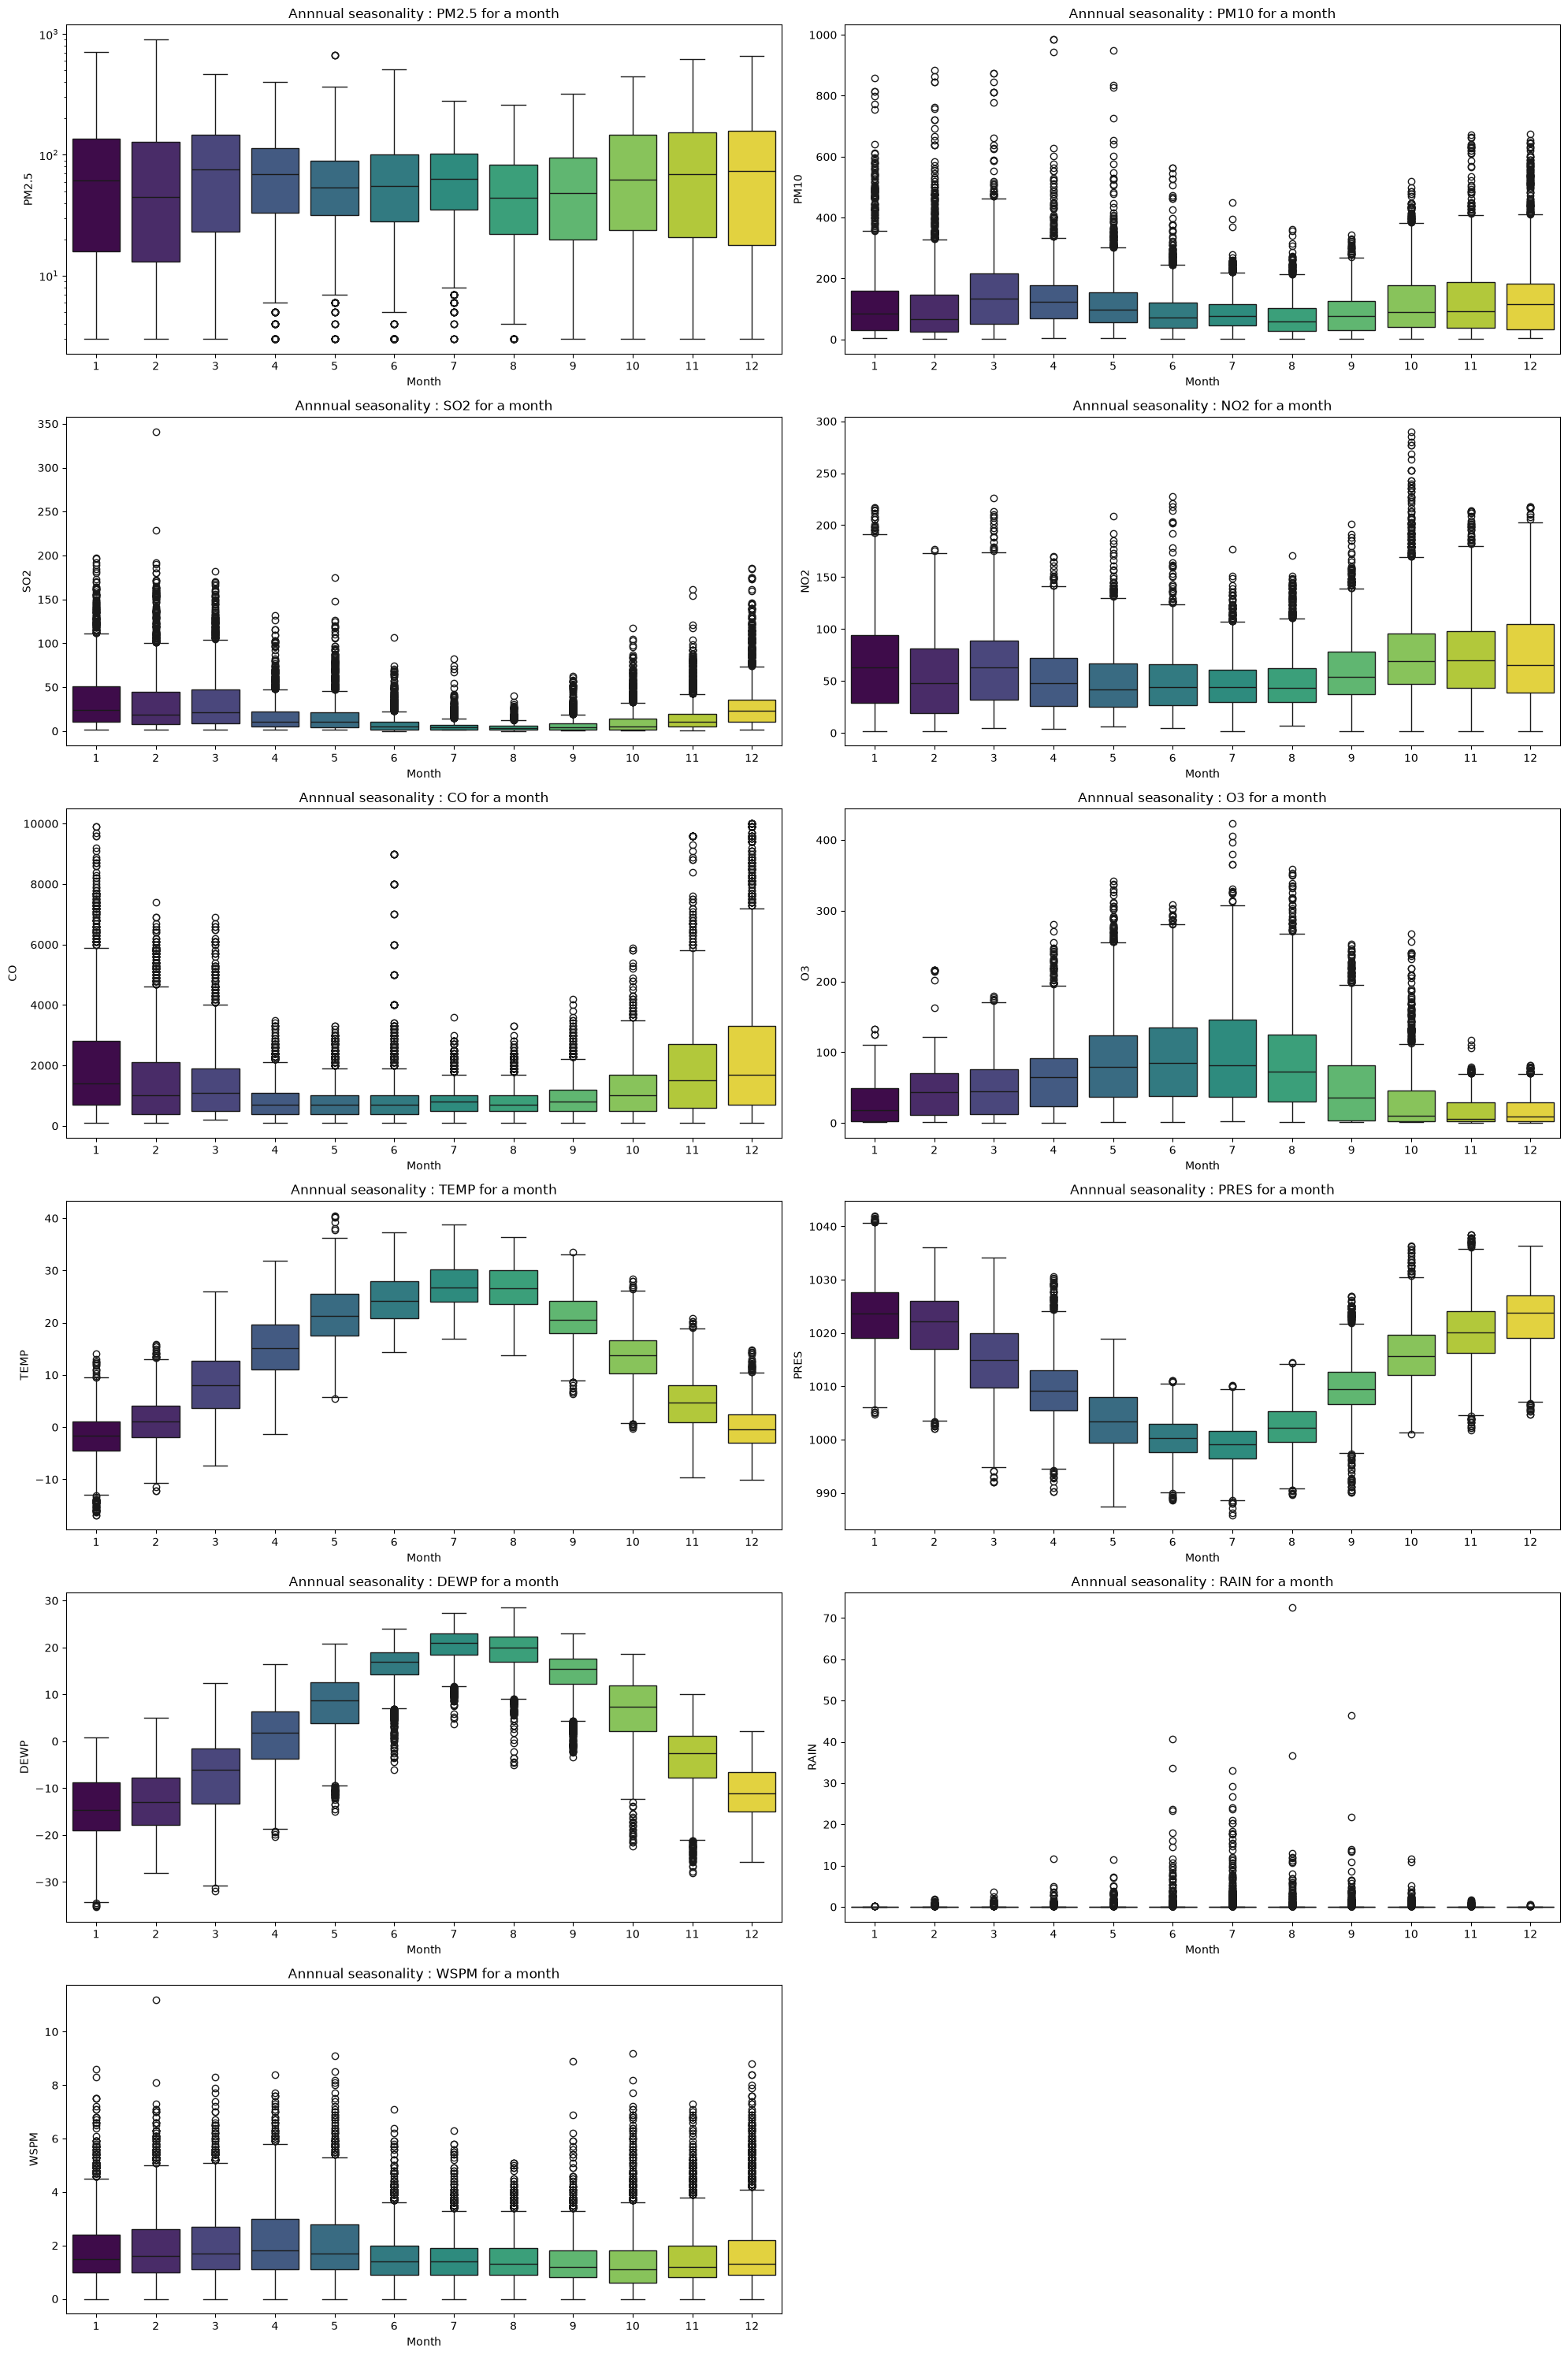

In [20]:
plt.figure(figsize=(20, 30))

for i, colonne in enumerate(features):
    plt.subplot(6, 2, i + 1)
    if colonne == "PM2.5": plt.yscale('log')

    sbn.boxplot(x='month', y=colonne, data=df_processed, hue='month', palette='viridis', legend=False)
    
    plt.title(f"Annnual seasonality : {colonne} for a month")
    plt.xlabel("Month")
    plt.ylabel(colonne)

plt.tight_layout()
plt.show()

Different scales => need to scale all the feature before training.

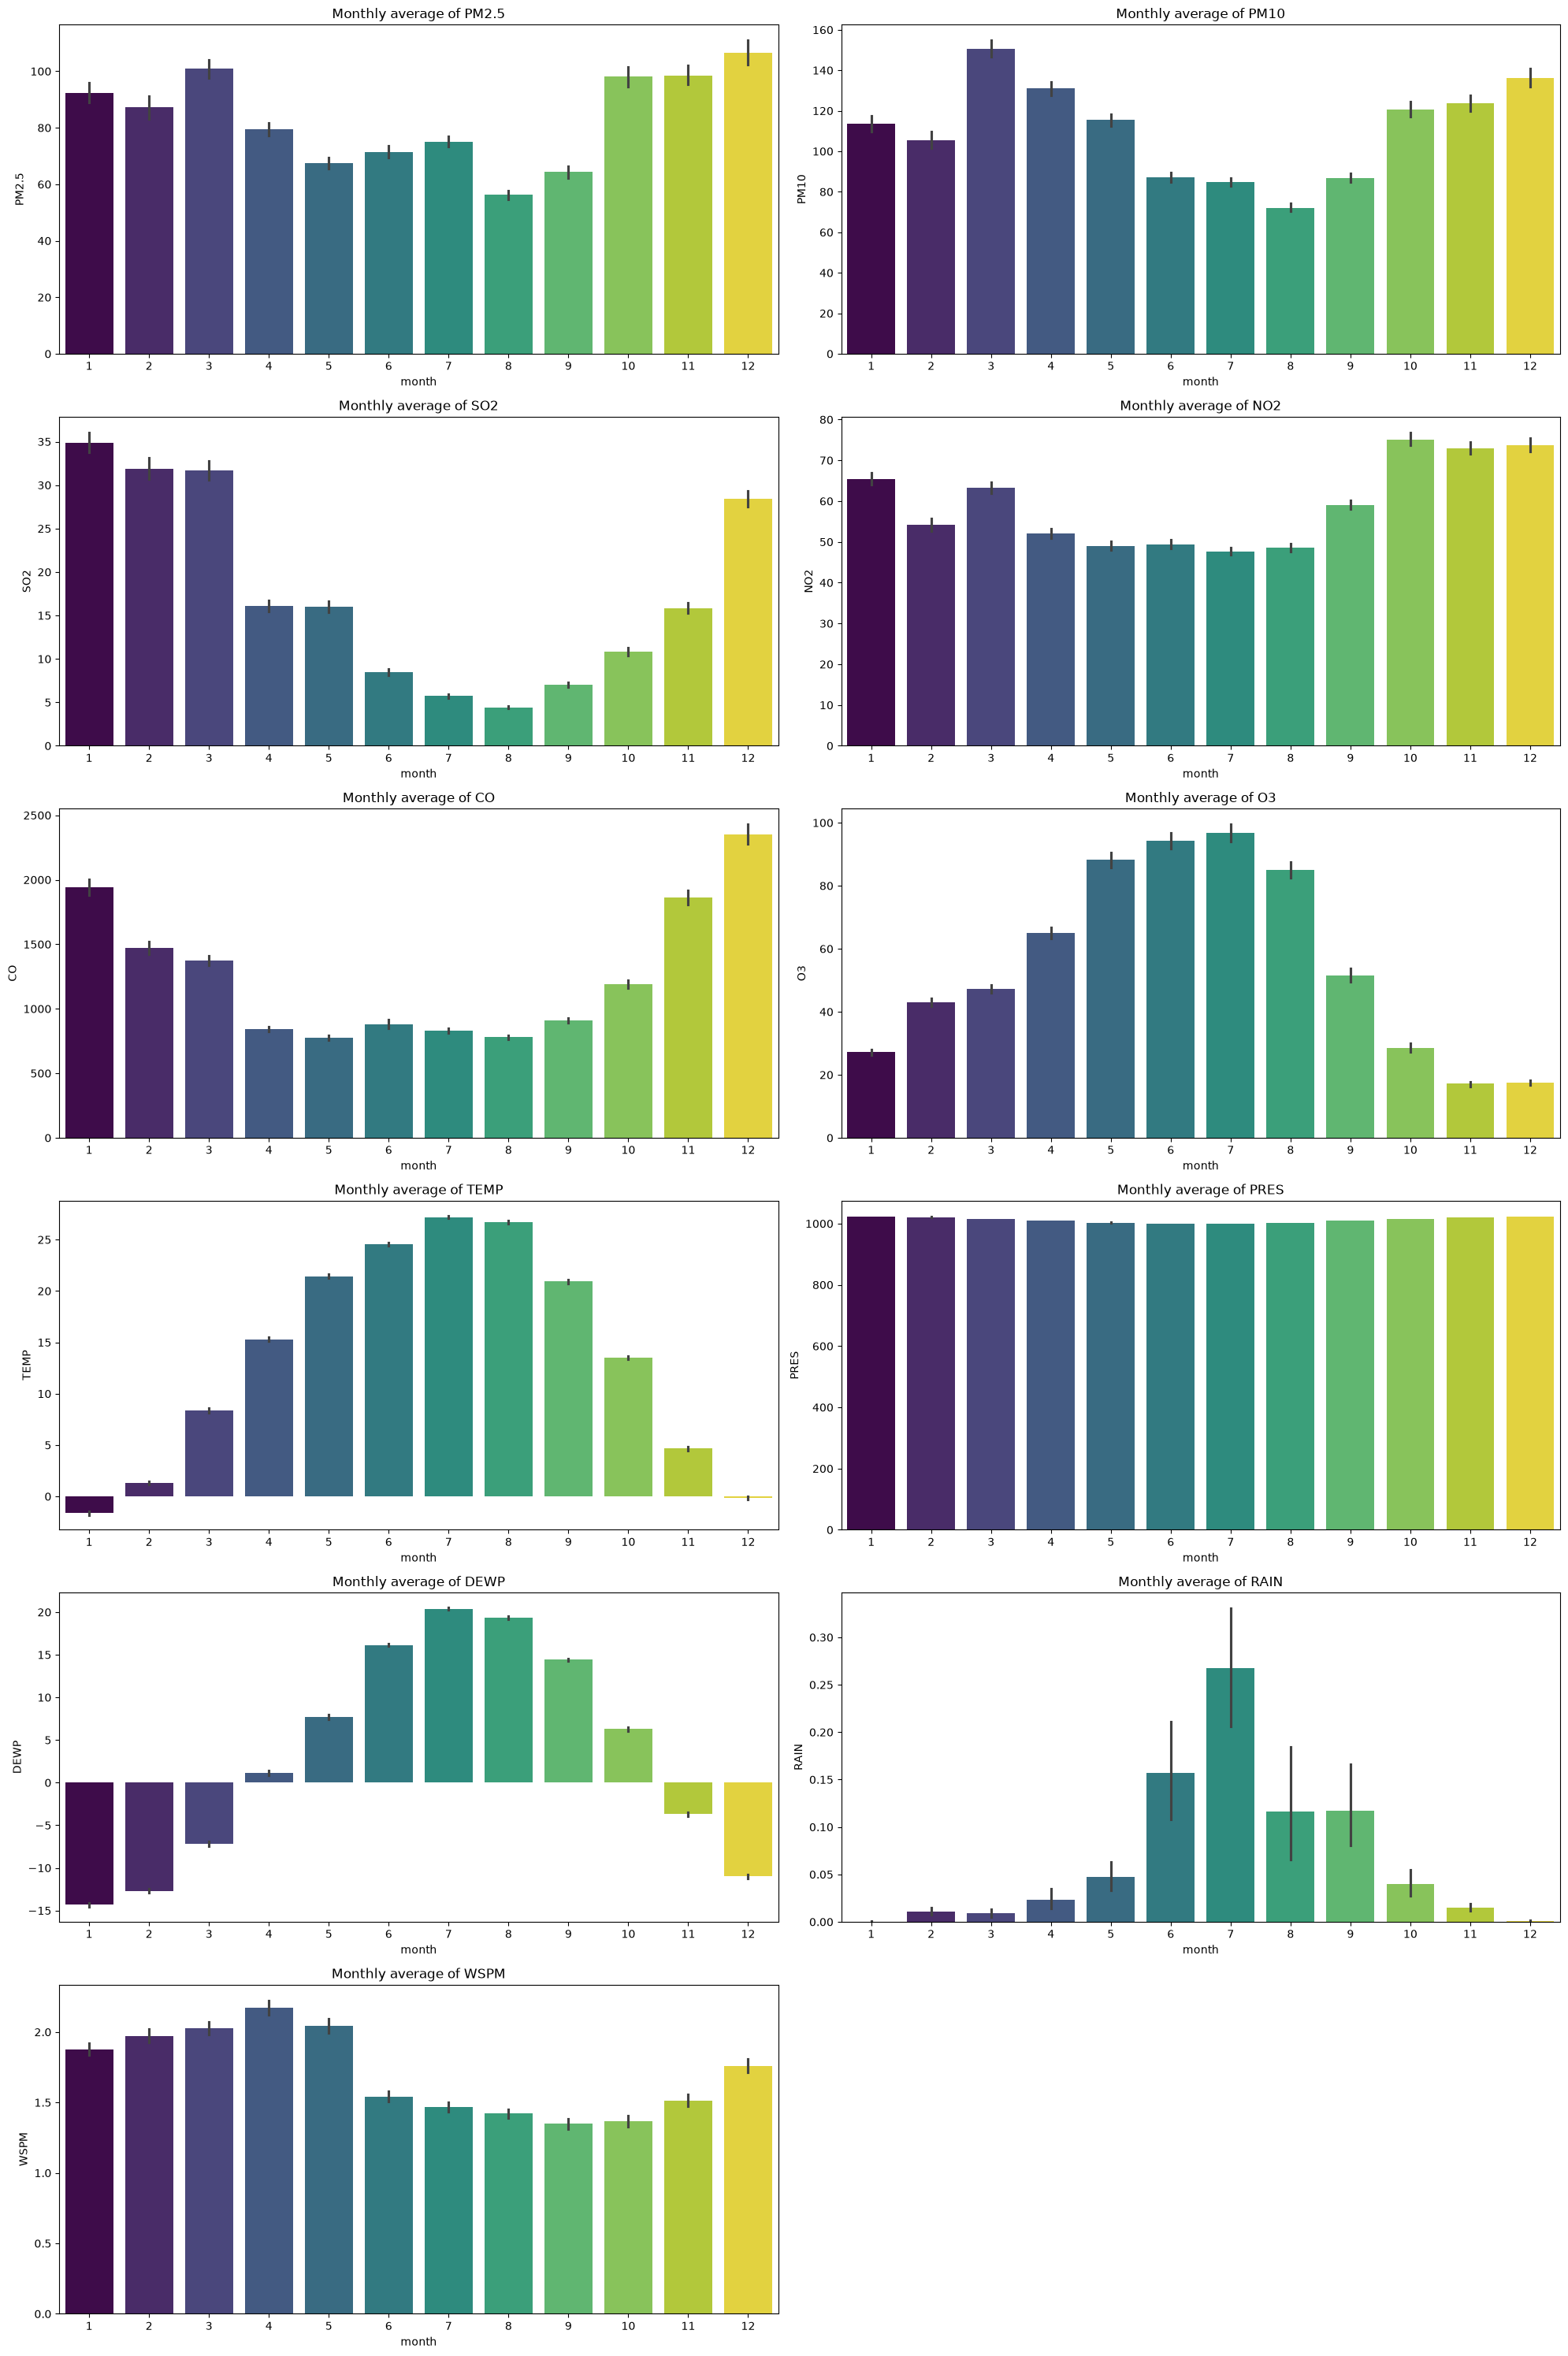

In [21]:
plt.figure(figsize=(20, 30))

for i, colonne in enumerate(features):
    plt.subplot(6, 2, i + 1)

    sbn.barplot(x='month', y=colonne, data=df_processed, hue='month', palette='viridis', legend=False)
    
    plt.title(f"Monthly average of {colonne}")
    plt.ylabel(colonne)

plt.tight_layout()
plt.show()

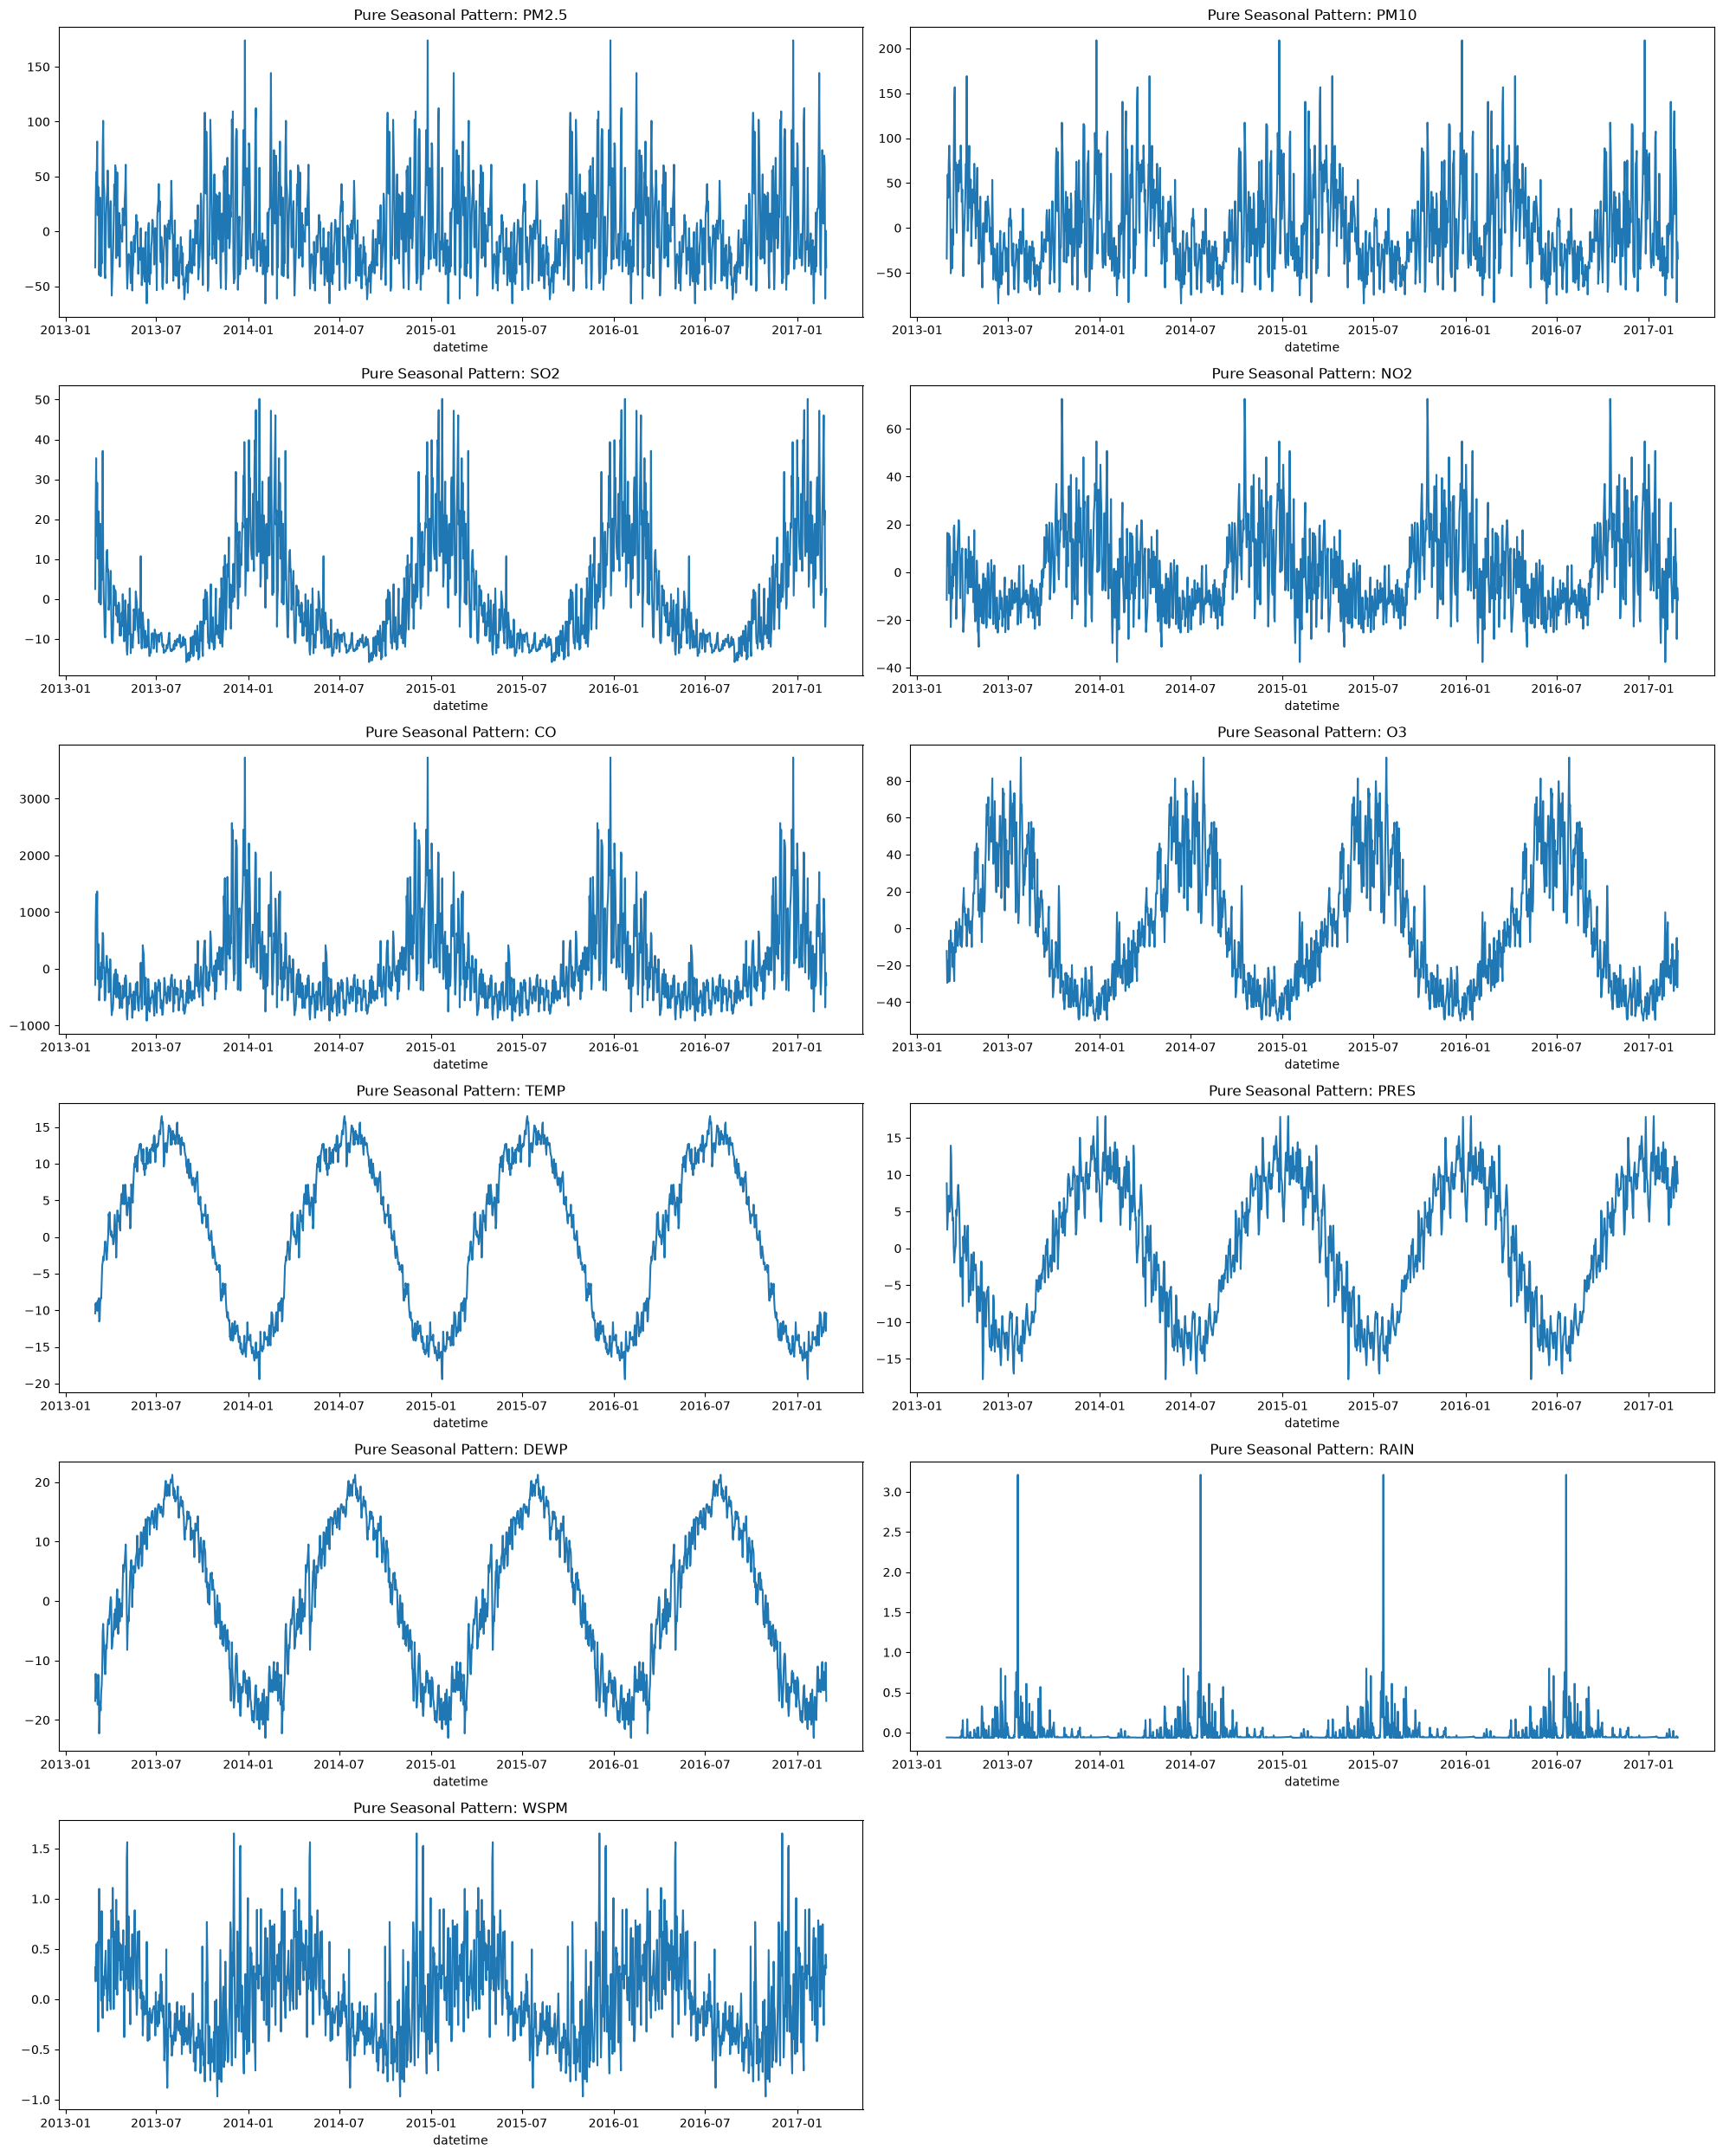

In [17]:
daily_data = df_processed.groupby(df_processed['datetime'].dt.date)[features].mean()
daily_data = daily_data.dropna()
plt.figure(figsize=(20, 25))
for i, colonne in enumerate(features):
    plt.subplot(6, 2, i + 1)
    
    # Decompose using a period of 365 (one year)
    decompo = seasonal_decompose(daily_data[colonne], model='additive', period=365)
    
    # Plot only the seasonal component
    decompo.seasonal.plot(ax=plt.gca(), title=f"Pure Seasonal Pattern: {colonne}")
    
plt.tight_layout()
plt.show()

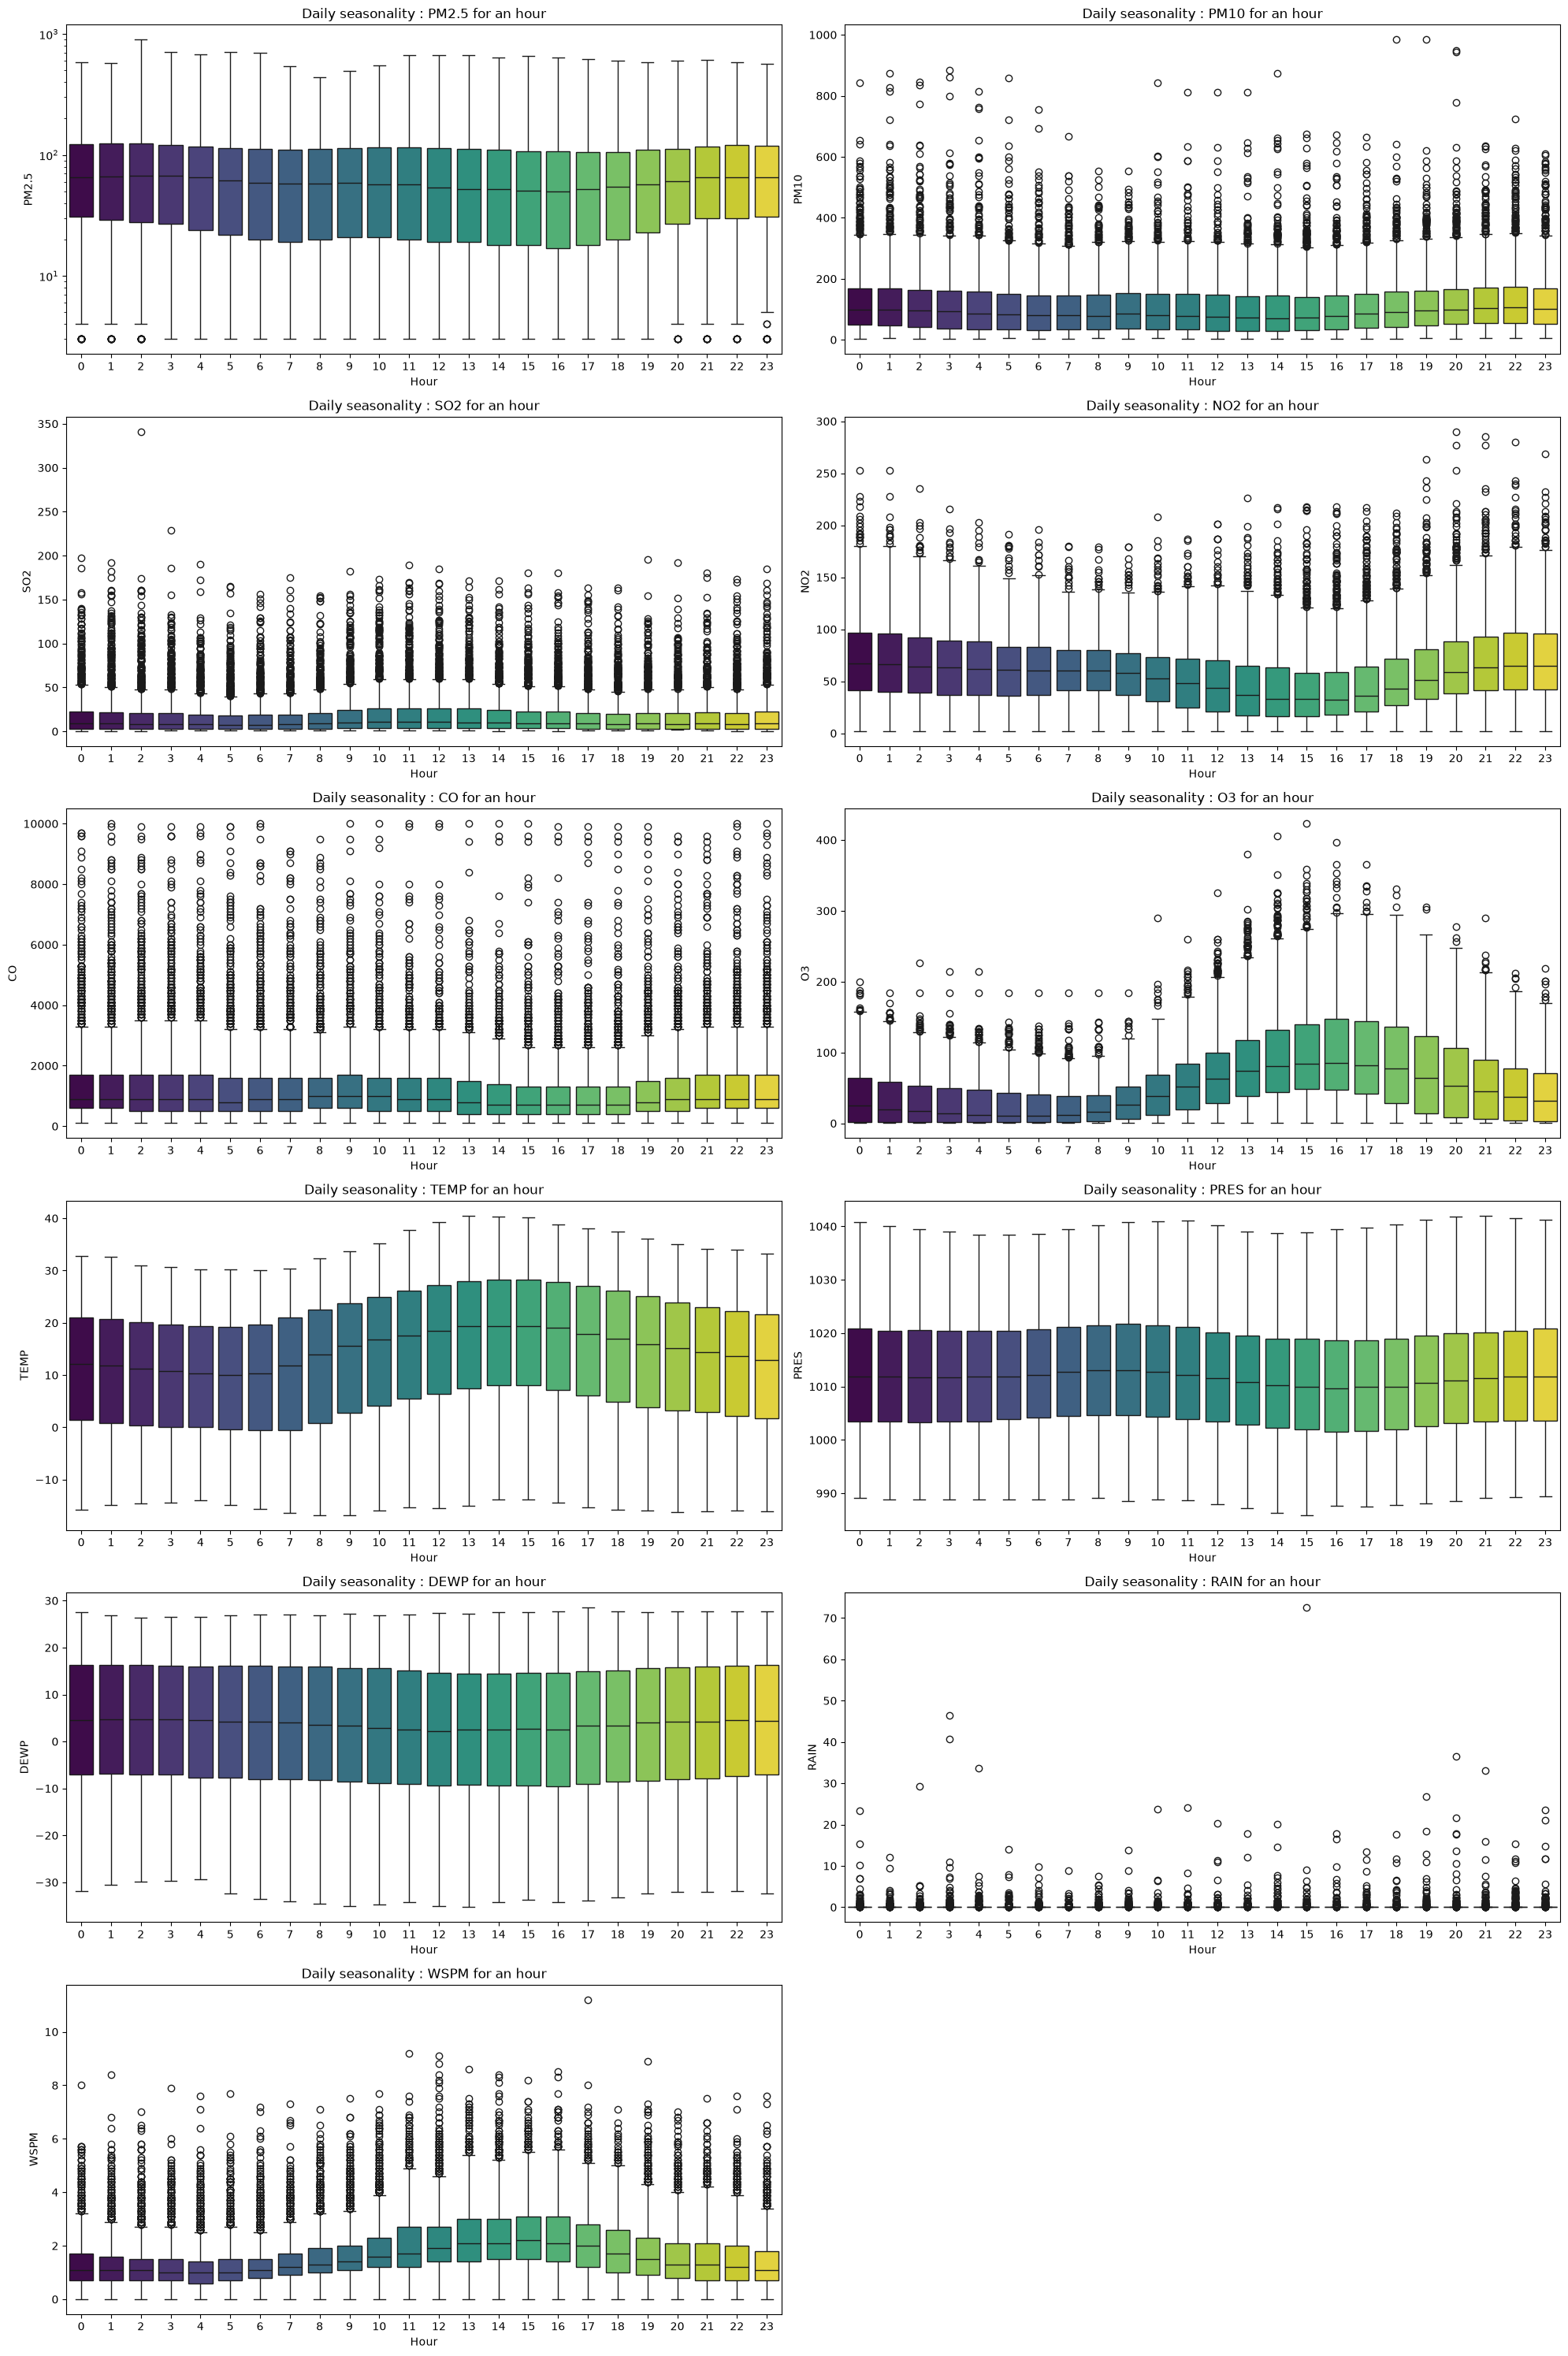

In [22]:
plt.figure(figsize=(20, 30))

for i, colonne in enumerate(features):
    plt.subplot(6, 2, i + 1)
    if colonne == "PM2.5": plt.yscale('log')
    sbn.boxplot(x='hour', y=colonne, data=df_processed, hue='hour', palette='viridis', legend=False)
    
    plt.title(f"Daily seasonality : {colonne} for an hour")
    plt.xlabel("Hour")
    plt.ylabel(colonne)

plt.tight_layout()
plt.show()

## 5. Cyclical encoding of time features

Seasonality is present, so we keep hour and month as features. We encode them cyclically (sin/cos) so the model understands that, e.g., 11pm is right before midnight.

In [ ]:
# we want to circle the hour and month so the model understant that 11 pm is juste beofre 12 am
# we want the model to be able to understand the cycle of the hour or month 

df_processed['hour_sin'] = np.sin(2 * np.pi * df_processed['hour'] / 24.0)
df_processed['hour_cos'] = np.cos(2 * np.pi * df_processed['hour'] / 24.0)

df_processed['month_sin'] = np.sin(2 * np.pi * df_processed['month'] / 12.0)
df_processed['month_cos'] = np.cos(2 * np.pi * df_processed['month'] / 12.0)

## 6. Conclusion and next steps

This exploration confirmed that PM2.5 has clear daily and yearly seasonality, is strongly correlated with the other pollutants (especially PM10) and with wind speed, and that the raw values are right-skewed. NaN values, wind direction, and hour/month were already handled above; the remaining steps below need to be consolidated into a single pipeline (`data.py`) before training.

**To do, in order:**
1. **Split into train / validation / test sets** - must be a **temporal split** to avoid leaking future information into training.
2. **Fill NaN values with forward fill** - already validated above; move this logic into `data.py` as the first preprocessing step, since every later step depends on having no missing values.
3. **One-hot encode wind direction** (`drop_first=True` to avoid the dummy variable trap).
4. **Add cyclical features for hour and month** (sin/cos).
5. **Build two feature-set versions of the target problem**: PM2.5 prediction *with* PM10 as a feature, and *without* it - to compare a baseline (easier, PM10 is a strong proxy) against a more genuinely challenging setup.

**Not yet covered, but needed right after this list:** feature scaling/normalization, computed on the train split only and applied unchanged to validation/test.
